# Joint TS maps and combined signififacnes maps 

Fermi-LAT and H.E.S.S. analysis example toward RXJ 1713.7-3946

In [1]:
import time

import astropy.units as u

import matplotlib.pyplot as plt 
from matplotlib import colors
from matplotlib.cm import ScalarMappable

import numpy as np 

from gammapy.datasets import Datasets
from gammapy.modeling.models import Models, PointSpatialModel, PowerLawSpectralModel, SkyModel
from gammapy.modeling import Fit
from gammapy.estimators import TSMapEstimator, ExcessMapEstimator
from gammapy.estimators.utils import get_combined_significance_maps
from gammapy.catalog import CATALOG_REGISTRY


plt.rcParams["font.size"] = 14


## Datasets setup

First we load the datasets previously created

In [2]:
pwd

'/Users/qremy/Work/GitHub/gammapy-2.0-paper/scripts/joint'

In [3]:
datasets_fermi = Datasets.read(
    filename="./datasets/fermi_lat_psf23_rxj_datasets.yaml", filename_models="./models/fermi_lat_psf23_rxj_models.yaml"
)

datasets_hess = Datasets.read(
    filename="./datasets/hess_rxj_joint_datasets.yaml", filename_models="./models/hess_rxj_joint_models.yaml"
)

/Users/qremy/Work/GitHub/gammapy/gammapy/utils/scripts.py:73: UserWarning: Checksum verification failed.
  warnings.warn("Checksum verification failed.", UserWarning)
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Parameter 'value' not defined in YAML file. Using default value: 1.0 sr-1
Parameter 'value' not defined in YAML file. Using default value: 1.0 sr-1
/Users/qremy/Work/GitHub/gammapy/gammapy/utils/scripts.py:73: UserWarning: Checksum verification failed.
  warnings.warn("Checksum verification failed.", UserWarning)


We create a joint datasets list

In [4]:
datasets = Datasets(list(datasets_fermi) + list(datasets_hess))
#TODO: we lack the addition on Datasets, who want to open a PR ?

We select are going to select only the fermi-lat models that are not seen by H.E.S.S.

In [5]:
models_hgps_geom = Models.read("./models/hgps_rxj_models.yaml")

In [6]:
fermi_sources = Models(datasets_fermi.models.select(name_substring="4FGL"))
selection = np.array([np.all(m.position.separation(models_hgps_geom.positions) > 0.1*u.deg) for m in fermi_sources])
fermi_sources_selection = fermi_sources[selection]

and the backgrounds

In [7]:
model_iem = Models(datasets_fermi.models[ "IEM_varmin_rescaled"])
models_fermi_iso = Models(datasets_fermi.models.select(tag="const", model_type="spatial"))
models_hess_bkg = Models(datasets_hess.models.select(tag="fov-bkg"))

You can check the `datasets_names` attribute on a given model to check on which dataset it is applied.
By default it is `None` and apply to everything.

Now we can assign the models to the datasets (and this will take into account `datasets_names` assignment)

In [8]:
models = fermi_sources_selection + model_iem + models_fermi_iso + models_hess_bkg
datasets.models = models

## Joint TS map

This use forward folding to convolve a given nev model by the IRFs and move it in every pixel to evalaute the significance of the excess above the existing models.

In [9]:
spatial_model = PointSpatialModel()
spectral_model = PowerLawSpectralModel(index=2)
model = SkyModel(spatial_model=spatial_model, spectral_model=spectral_model)

ts_estimator = TSMapEstimator(
    model,
    kernel_width="1 deg",  # set this close to the 95-99% containment radius of the PSF
    selection_optional=[],
    sum_over_energy_groups=True,
    energy_edges=[10, 1000] * u.GeV,
    n_jobs=4, #this will run in parallel
)


In [10]:
%%time
ts_results_fermi = ts_estimator.run(datasets_fermi)

CPU times: user 14 s, sys: 1.41 s, total: 15.4 s
Wall time: 22.7 s


In [11]:
%%time
ts_results_hess = ts_estimator.run(datasets_hess)

HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
Position <SkyCoord (ICRS): (ra, dec) in deg
    (255.02960205, -40.22290039)> is outside valid IRF map range, using nearest IRF defined within
Position <SkyCoord (ICRS): (ra, dec) in deg
    (255.02960205, -40.22290039)> is outside valid IRF map range, using nearest IRF defined within
Model 4FGL J1704.8-4030 is outside the target geom but contributes inside through the psf.This contribution cannot be estimated precisely.Consider extending the dataset geom and/or the masked margin in the mask_fit.
Model 4FGL J1705.2-3850 is outside the target geom but contributes inside through the psf.This contribution cannot be estimated precisely.Consider extending the dataset geom and/or the masked margin

CPU times: user 3min 1s, sys: 10.3 s, total: 3min 11s
Wall time: 3min 38s


In [12]:
%%time
ts_results_joint = ts_estimator.run(datasets)

Position <SkyCoord (ICRS): (ra, dec) in deg
    (255.02960205, -40.22290039)> is outside valid IRF map range, using nearest IRF defined within
Position <SkyCoord (ICRS): (ra, dec) in deg
    (255.02960205, -40.22290039)> is outside valid IRF map range, using nearest IRF defined within
Model 4FGL J1704.8-4030 is outside the target geom but contributes inside through the psf.This contribution cannot be estimated precisely.Consider extending the dataset geom and/or the masked margin in the mask_fit.
Model 4FGL J1705.2-3850 is outside the target geom but contributes inside through the psf.This contribution cannot be estimated precisely.Consider extending the dataset geom and/or the masked margin in the mask_fit.
Model 4FGL J1706.2-4113c is outside the target geom but contributes inside through the psf.This contribution cannot be estimated precisely.Consider extending the dataset geom and/or the masked margin in the mask_fit.
Model 4FGL J1706.5-4023c is outside the target geom but contribut

CPU times: user 3min 7s, sys: 12.4 s, total: 3min 19s
Wall time: 4min 4s


Let's plot everything together

/var/folders/c6/mnwlhxw94_b2r4wqsh2d16d80000gp/T/ipykernel_53540/3372055677.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


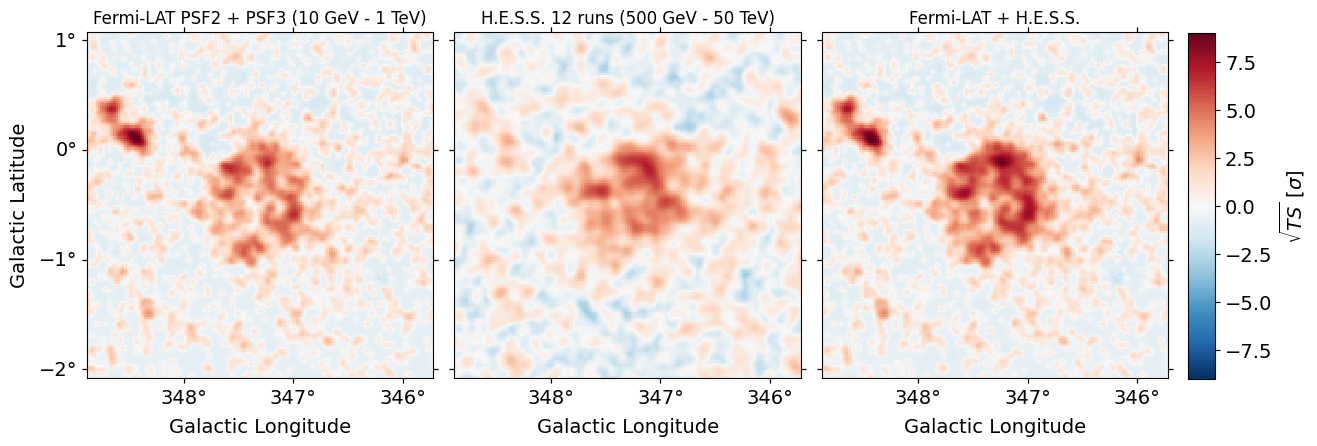

In [13]:

def plot_cutout(image, ax, plot_kwargs=None, margin=2*u.deg):
    image = image.cutout(
        image.geom.center_skydir, width=np.max(image.geom.width) - 2 * margin
    )
    kwargs = dict(ax=ax)
    if plot_kwargs : 
        kwargs.update(plot_kwargs)
    image.plot(**kwargs)

margin=2.42*u.deg
geom = datasets[0].counts.geom
fig_geom = geom.cutout(geom.center_skydir, width=np.max(geom.width) - 2 * margin)
resi_kwargs =dict(
        clim=[-9, 9],
        cmap=plt.cm.RdBu_r,
        add_cbar=False,
    )

fig = plt.figure(figsize=(12, 5))
ax1 = plt.subplot(131, projection=fig_geom.wcs)
plot_cutout(ts_results_fermi["sqrt_ts"], ax1, resi_kwargs, margin)
ax1.set_title("Fermi-LAT PSF2 + PSF3 (10 GeV - 1 TeV)", fontsize=12)

ax2 = plt.subplot(132, projection=fig_geom.wcs)
plot_cutout(ts_results_hess["sqrt_ts"], ax2, resi_kwargs, margin)
ax2.set_title("H.E.S.S. 12 runs (500 GeV - 50 TeV)", fontsize=12)
ax2.tick_params(axis="y", labelbottom=False)

ax3 = plt.subplot(133, projection=fig_geom.wcs)
plot_cutout(ts_results_joint["sqrt_ts"], ax3, resi_kwargs, margin)
ax3.set_title("Fermi-LAT + H.E.S.S.", fontsize=12)
ax3.tick_params(axis="y", labelbottom=False)

norm = colors.Normalize(vmin=resi_kwargs["clim"][0], vmax=resi_kwargs["clim"][1])
sm = ScalarMappable(norm=norm, cmap=resi_kwargs["cmap"])
sm.set_array([])

cb_ax = fig.add_axes([ .999, .21, 0.023 , .691])
cb = fig.colorbar(sm, cax=cb_ax, orientation='vertical')  
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=14)
cb.ax.set_ylabel(r"$\sqrt{TS}$ [$\sigma$]", fontsize=14)


plt.tight_layout()


## Excess Maps

This use backward folding to estimate the TS and the flux in a given correlation radius.
In that case the predicted counts are the excess counts. The flux is the excess counts divided by the reconstructed exposure. So only the flux depends on the spectral model assumption not the TS.

In [14]:
estimator_rcorr0p1 = ExcessMapEstimator(correlation_radius="0.1 deg", spectral_model=spectral_model)

This will give use one estimation per dataset that we can combine together using `get_combined_significance_maps`.

The significance computation assumes that the model contains one degree of freedom per valid energy bin in each dataset.
This method implemented here is valid under the assumption that the TS in each independent bin follows a Chi2 distribution,
then the sum of the TS also follows a Chi2 distribution (with the sum of degree of freedom).

In [15]:
#get_combined_significance_maps?

In [16]:
%%time
results_combined_fermi_rcorr0p1 = get_combined_significance_maps(estimator_rcorr0p1, datasets_fermi)


CPU times: user 3.23 s, sys: 582 ms, total: 3.81 s
Wall time: 3.92 s


In [17]:
%%time
results_combined_hess_rcorr0p1 = get_combined_significance_maps(estimator_rcorr0p1, datasets_hess)


Position <SkyCoord (ICRS): (ra, dec) in deg
    (255.02960205, -40.22290039)> is outside valid IRF map range, using nearest IRF defined within
Position <SkyCoord (ICRS): (ra, dec) in deg
    (255.02960205, -40.22290039)> is outside valid IRF map range, using nearest IRF defined within
Model 4FGL J1704.8-4030 is outside the target geom but contributes inside through the psf.This contribution cannot be estimated precisely.Consider extending the dataset geom and/or the masked margin in the mask_fit.
Model 4FGL J1705.2-3850 is outside the target geom but contributes inside through the psf.This contribution cannot be estimated precisely.Consider extending the dataset geom and/or the masked margin in the mask_fit.
Model 4FGL J1706.2-4113c is outside the target geom but contributes inside through the psf.This contribution cannot be estimated precisely.Consider extending the dataset geom and/or the masked margin in the mask_fit.
Model 4FGL J1706.5-4023c is outside the target geom but contribut

CPU times: user 2min 34s, sys: 6.77 s, total: 2min 40s
Wall time: 2min 44s


In [18]:
%%time
results_combined_rcorr0p1 = get_combined_significance_maps(estimator_rcorr0p1, datasets)


CPU times: user 3.53 s, sys: 825 ms, total: 4.35 s
Wall time: 4.1 s


This approach is much faster than the TS map compuation but less precise in particular close to TS=0 where the validity of the hypostheses might break. However above few sigma this will point us toward the same excesses. As it is much faster we can test more model hypothesis in term of sizes, or scan the full Galactic Plane very efficiently.

/var/folders/c6/mnwlhxw94_b2r4wqsh2d16d80000gp/T/ipykernel_53540/2393513404.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


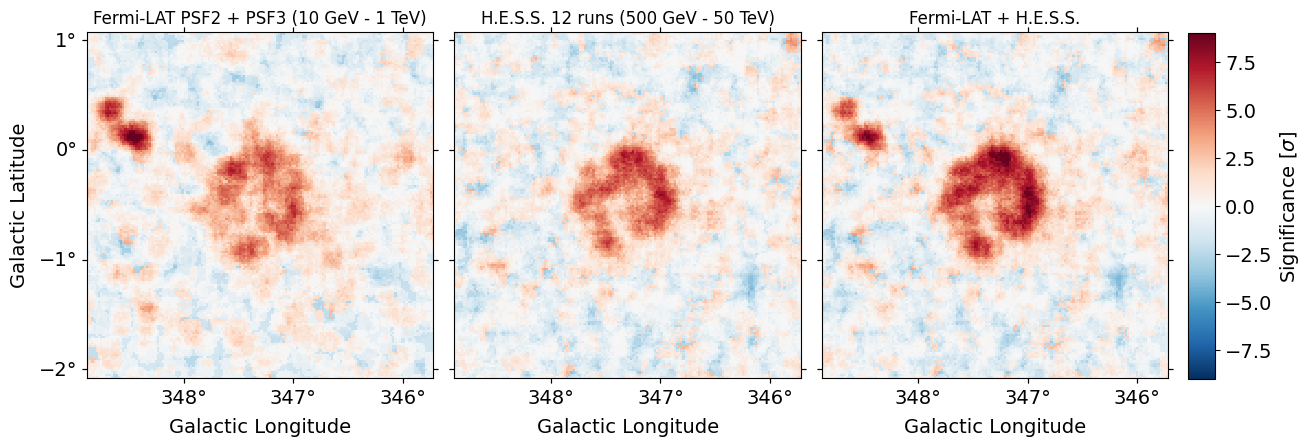

In [19]:

fig = plt.figure(figsize=(12, 5))
ax1 = plt.subplot(131, projection=fig_geom.wcs)
plot_cutout(results_combined_fermi_rcorr0p1["significance"], ax1, resi_kwargs, margin)
ax1.set_title("Fermi-LAT PSF2 + PSF3 (10 GeV - 1 TeV)", fontsize=12)

ax2 = plt.subplot(132, projection=fig_geom.wcs)
plot_cutout(results_combined_hess_rcorr0p1["significance"], ax2, resi_kwargs, margin)
ax2.set_title("H.E.S.S. 12 runs (500 GeV - 50 TeV)", fontsize=12)
ax2.tick_params(axis="y", labelbottom=False)

ax3 = plt.subplot(133, projection=fig_geom.wcs)
plot_cutout(results_combined_rcorr0p1["significance"], ax3, resi_kwargs, margin)
ax3.set_title("Fermi-LAT + H.E.S.S.", fontsize=12)
ax3.tick_params(axis="y", labelbottom=False)

norm = colors.Normalize(vmin=resi_kwargs["clim"][0], vmax=resi_kwargs["clim"][1])
sm = ScalarMappable(norm=norm, cmap=resi_kwargs["cmap"])
sm.set_array([])

cb_ax = fig.add_axes([ .999, .21, 0.023 , .691])
cb = fig.colorbar(sm, cax=cb_ax, orientation='vertical')  
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=14)
cb.ax.set_ylabel(r"Significance [$\sigma$]", fontsize=14)

plt.tight_layout()
